Question 1: What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples ?

- Anomaly Detection is a technique in machine learning used to identify unusual patterns, rare events, or data points that do not follow the expected behavior of a dataset. These unusual observations are called anomalies or outliers.

Types of Anomalies
1. Point Anomaly (Global Outlier)

A single data point that is significantly different from the rest of the data.

✅ Example:
In a dataset of daily temperatures (30°C, 32°C, 31°C, 29°C), a value like 50°C is an anomaly.
In banking, a sudden transaction of ₹10 lakh from a low-income user.

👉 Here, the anomaly is obvious when compared to the entire dataset.

2. Contextual Anomaly (Conditional Outlier)

A data point is considered anomalous only in a specific context (like time, location, etc.).

✅ Example:
Temperature of 15°C:
Normal in winter ❄️
Anomalous in summer ☀️
High website traffic at midnight might be suspicious but normal during the day.

👉 The anomaly depends on the context (time, season, location).

3. Collective Anomaly

A group of data points together behaves abnormally, even if individual points seem normal.

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.

- | Feature               | Isolation Forest                       | DBSCAN                               | Local Outlier Factor (LOF)            |
| --------------------- | -------------------------------------- | ------------------------------------ | ------------------------------------- |
| **Approach**          | Tree-based isolation                   | Density-based clustering             | Density-based (local comparison)      |
| **Working Principle** | Random splits isolate anomalies faster | Sparse points treated as noise       | Compares local density with neighbors |
| **Data Requirement**  | Works well with high-dimensional data  | Works best with spatial/density data | Works well with local structure data  |
| **Need for Labels**   | No (unsupervised)                      | No (unsupervised)                    | No (unsupervised)                     |
| **Parameters**        | Number of trees, sample size           | ε (epsilon), minPts                  | Number of neighbors (k)               |
| **Handling Noise**    | Explicitly detects anomalies           | Naturally identifies noise points    | Detects local outliers                |
| **Scalability**       | High (efficient for large datasets)    | Moderate                             | Moderate to low                       |
| **Cluster Shape**     | Not applicable                         | Arbitrary shapes                     | Not for clustering                    |


Question 3: What are the key components of a Time Series? Explain each with one
example.

- 🔹 Key Components of a Time Series

A time series is generally composed of four main components:

1. Trend (T)

The long-term movement or direction in the data over time.

It shows whether data is increasing, decreasing, or stable over a long period.
✅ Example:
A company’s sales increasing every year due to business growth.
Population growth over decades.

👉 Represents overall direction

2. Seasonal Component (S)

Regular and repeating patterns that occur at fixed time intervals (daily, monthly, yearly).

Caused by seasonal factors like weather, festivals, or habits.
✅ Example:
Ice cream sales increase every summer and decrease in winter.
Retail sales spike during festivals like Diwali.


3. Cyclical Component (C)

Fluctuations that occur over a longer and irregular period (not fixed like seasonality).

Often influenced by economic or business cycles.
✅ Example:
Economic boom and recession cycles affecting stock markets.
Rise and fall in real estate prices over years.

4. Irregular Component (I) (Random / Noise)

Unpredictable, random variations in the data.

Caused by sudden or unexpected events.
✅ Example:
Sudden drop in stock prices due to a global crisis.
Unexpected spike in sales due to viral marketing

Question 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one ?

- 🔹 What is Stationarity in Time Series?

A time series is said to be stationary if its statistical properties remain constant over time.

👉 In simple terms:
Mean → constant
Variance → constant
Covariance (autocorrelation) → depends only on lag, not time
✅ Example:
White noise data (random but stable behavior over time)
❌ Non-stationary example:
Stock prices (trend + changing variance)
🔹 Why Stationarity is Important?

Most time series models like ARIMA model assume stationarity.
If the data is non-stationary, predictions become unreliable.

🔹 How to Test Stationarity?
1. Visual Inspection
Plot the data
Check for:
Trend (upward/downward)
Changing variance
Seasonality

👉 If present → likely non-stationary

2. Statistical Tests
✅ Augmented Dickey-Fuller Test (ADF)
Most commonly used test
Hypothesis:
H₀ (Null): Data is non-stationary
H₁ (Alternative): Data is stationary
Decision:
If p-value < 0.05 → stationary
If p-value > 0.05 → non-stationary
3. Rolling Statistics
Compute rolling mean & variance
If they change over time → non-stationary
🔹 How to Convert Non-Stationary → Stationary?
1. Differencing

Subtract previous value from current value:

𝑌
′
=
𝑌
𝑡
−
𝑌
𝑡
−
1
Y
′
=Y
t
	​

−Y
t−1
	​

Removes trend
✅ Example:
Stock price → price changes (returns)
2. Log Transformation

Apply logarithm:

𝑌
′
=
log
⁡
(
𝑌
)
Y
′
=log(Y)
Stabilizes variance
✅ Example:
Exponential growth data
3. Moving Average (Smoothing)
Removes noise and trend
Helps stabilize mean
4. Seasonal Differencing

Subtract value from previous season:

𝑌
′
=
𝑌
𝑡
−
𝑌
𝑡
−
𝑠
Y
′
=Y
t
	​

−Y
t−s
	​

Removes seasonality
✅ Example:
Monthly data → subtract value from same month last year
5. Detrending
Remove trend using regression or decomposition

Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.?

- | Model   | Structure              | Key Idea           | Handles             | Use Case               |
| ------- | ---------------------- | ------------------ | ------------------- | ---------------------- |
| AR      | Past values            | Self-dependence    | Stationary data     | Temperature prediction |
| MA      | Past errors            | Noise modeling     | Stationary data     | Stock noise            |
| ARIMA   | AR + I + MA            | Trend + noise      | Non-stationary      | Sales forecasting      |
| SARIMA  | ARIMA + Seasonality    | Seasonal patterns  | Seasonal data       | Monthly trends         |
| SARIMAX | SARIMA + External vars | External influence | Seasonal + external | Business forecasting   |


Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:

df = pd.read_csv('/content/AirPassengers.csv')

df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)

print(df.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


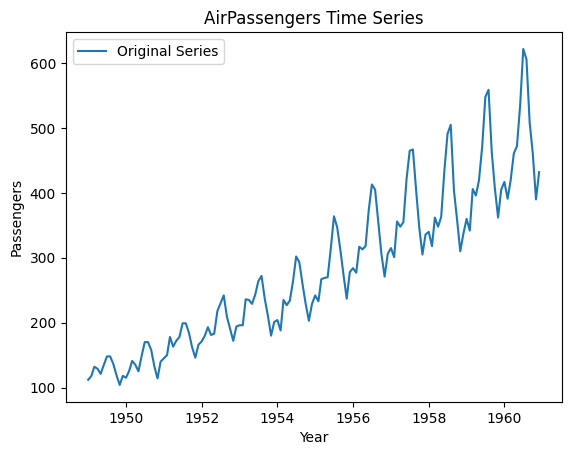

In [4]:
plt.figure()
plt.plot(df, label='Original Series')
plt.title('AirPassengers Time Series')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [5]:
decomposition = seasonal_decompose(df, model='multiplicative')

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

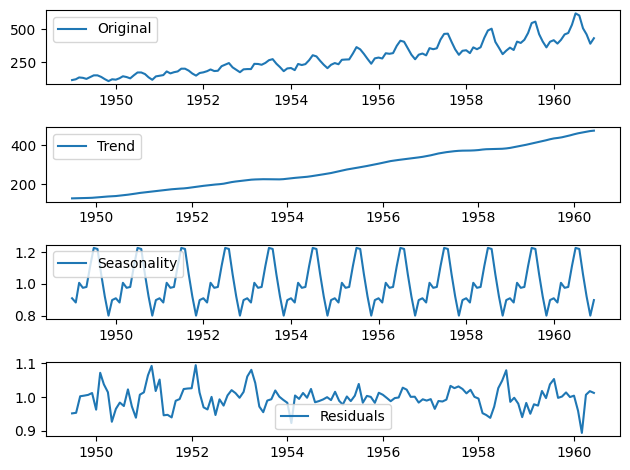

In [6]:
plt.figure()

plt.subplot(4,1,1)
plt.plot(df, label='Original')
plt.legend()

plt.subplot(4,1,2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality')
plt.legend()

plt.subplot(4,1,4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [28]:
import numpy as np

# Generate synthetic data for NYC Taxi Fare
np.random.seed(42)
num_samples = 500

# Normal taxi trips
trip_distance_normal = np.random.normal(loc=3, scale=1.5, size=num_samples)
fare_amount_normal = 2.5 * trip_distance_normal + np.random.normal(loc=3, scale=2, size=num_samples)

# Introduce some anomalies:
# 1. Very long trip, very low fare
outlier1_dist = np.random.uniform(low=15, high=25, size=10)
outlier1_fare = np.random.normal(loc=10, scale=2, size=10)

# 2. Very short trip, very high fare
outlier2_dist = np.random.uniform(low=0.1, high=0.5, size=10)
outlier2_fare = np.random.normal(loc=50, scale=10, size=10)

# Combine normal and anomalous data
trip_distance = np.concatenate([trip_distance_normal, outlier1_dist, outlier2_dist])
fare_amount = np.concatenate([fare_amount_normal, outlier1_fare, outlier2_fare])

# Ensure non-negative values
trip_distance[trip_distance < 0] = np.random.uniform(0.1, 0.5)
fare_amount[fare_amount < 0] = np.random.uniform(2, 5)

df = pd.DataFrame({
    'trip_distance': trip_distance,
    'fare_amount': fare_amount
})

print(df.head())

   trip_distance  fare_amount
0       3.745071    14.215033
1       2.792604    13.800342
2       3.971533    10.131697
3       5.284545    17.337300
4       2.648770     8.320640


In [30]:
# The 'data' for Isolation Forest will be the entire DataFrame 'df' now
data = df

# No need for dropna() if synthetic data is clean

In [31]:
model = IsolationForest(contamination=0.05, random_state=42)

data['anomaly'] = model.fit_predict(data)


print(data['anomaly'].value_counts())

anomaly
 1    494
-1     26
Name: count, dtype: int64


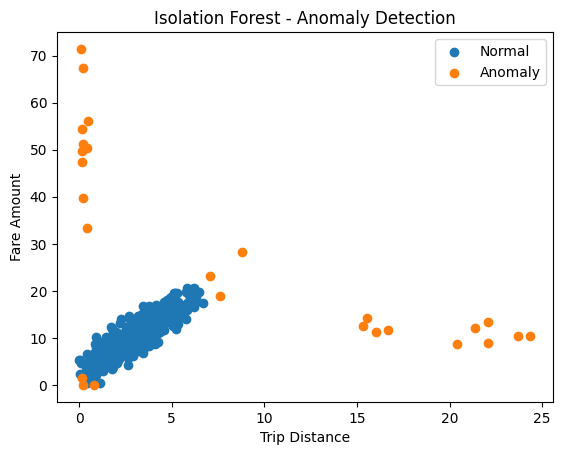

In [32]:
plt.figure()


normal = data[data['anomaly'] == 1]
plt.scatter(normal['trip_distance'], normal['fare_amount'], label='Normal')

anomaly = data[data['anomaly'] == -1]
plt.scatter(anomaly['trip_distance'], anomaly['fare_amount'], label='Anomaly')

plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Isolation Forest - Anomaly Detection')
plt.legend()
plt.show()

In [34]:
model = IsolationForest(contamination=0.05, random_state=42)

data['anomaly'] = model.fit_predict(data)


print(data['anomaly'].value_counts())

anomaly
 1    494
-1     26
Name: count, dtype: int64


In [33]:
model = IsolationForest(contamination=0.05, random_state=42)

data['anomaly'] = model.fit_predict(data)


print(data['anomaly'].value_counts())

anomaly
 1    494
-1     26
Name: count, dtype: int64


Question 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [18]:
# Load dataset
df = pd.read_csv('/content/AirPassengers.csv')

# Convert to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set index
df.set_index('Month', inplace=True)

# View data
print(df.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


In [19]:
model = SARIMAX(df['#Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Wed, 25 Mar 2026   AIC                           1022.299
Time:                                    18:14:29   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

In [20]:
forecast = results.forecast(steps=12)

print(forecast)

1961-01-01    449.330269
1961-02-01    424.386564
1961-03-01    459.033907
1961-04-01    497.865803
1961-05-01    509.863877
1961-06-01    568.258851
1961-07-01    655.811113
1961-08-01    641.191479
1961-09-01    546.393734
1961-10-01    496.801909
1961-11-01    427.675571
1961-12-01    471.237421
Freq: MS, Name: predicted_mean, dtype: float64


/tmp/ipykernel_899/1561234398.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=df.index[-1], periods=13, freq='M')[1:]


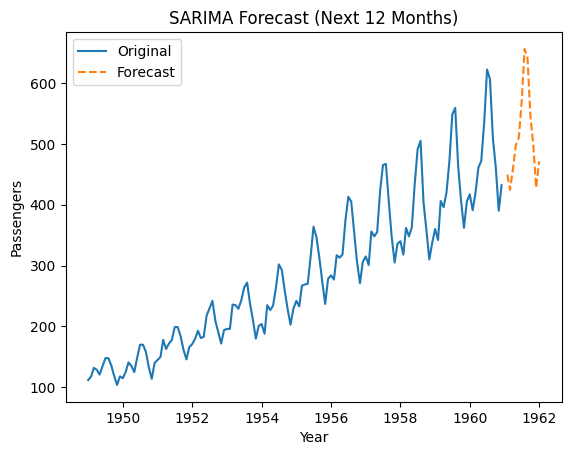

In [21]:
plt.figure()

# Original data
plt.plot(df, label='Original')

# Forecast index
forecast_index = pd.date_range(start=df.index[-1], periods=13, freq='M')[1:]

# Plot forecast
plt.plot(forecast_index, forecast, label='Forecast', linestyle='--')

plt.title('SARIMA Forecast (Next 12 Months)')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

In [23]:
# Create synthetic dataset
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=1.0, random_state=42)

# Add some outliers manually
rng = np.random.RandomState(42)
outliers = rng.uniform(low=-6, high=6, size=(20, 2))

# Combine data
X = np.vstack([X, outliers])

In [24]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# Fit and predict
y_pred = lof.fit_predict(X)

# -1 = anomaly, 1 = normal

In [25]:
normal = X[y_pred == 1]
anomaly = X[y_pred == -1]

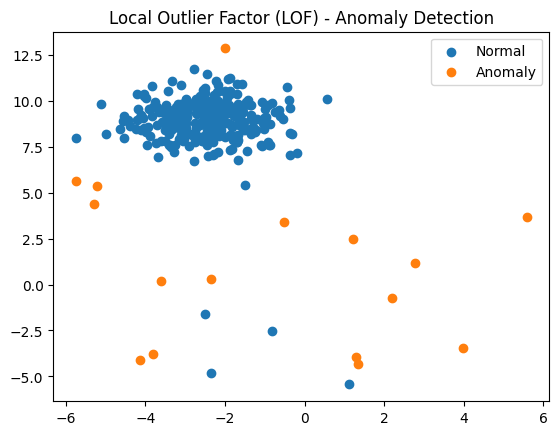

In [26]:
plt.figure()

# Plot normal points
plt.scatter(normal[:, 0], normal[:, 1], label='Normal')

# Plot anomalies
plt.scatter(anomaly[:, 0], anomaly[:, 1], label='Anomaly')

plt.title('Local Outlier Factor (LOF) - Anomaly Detection')
plt.legend()
plt.show()

Question 10: You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:
● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?
● How would you validate and monitor the performance over time?
● How would this solution help business decisions or operations?

--  Real-Time Data Science Workflow for Power Grid Monitoring

To forecast energy demand and detect anomalies in real-time power consumption data, a structured data science pipeline is required.

1. Anomaly Detection in Streaming Data

For detecting abnormal spikes or drops:

Isolation Forest is preferred for real-time systems because it is fast, scalable, and works well with high-dimensional data (e.g., weather + usage). It isolates anomalies using random partitioning.
Local Outlier Factor (LOF) can be used for detecting local anomalies, especially when different regions have different consumption patterns.
DBSCAN detects density-based anomalies but is less suitable for real-time streaming due to higher computational cost.

👉 Final choice: Use Isolation Forest as the primary method, with LOF for region-specific validation.

2. Time Series Forecasting Model
SARIMAX is the most suitable model because it handles:
Trend
Seasonality (daily/weekly patterns)
External variables (weather, region)
Models like ARIMA and SARIMA are limited as they do not fully utilize external factors.

👉 Example: Temperature influences electricity demand (AC usage).

3. Validation and Performance Monitoring
Offline Validation:
Use time-based train-test split
Evaluation metrics:
MAE (Mean Absolute Error)
RMSE (Root Mean Square Error)
Online Monitoring:
Continuously compare predicted vs actual values
Detect concept drift (changes in consumption patterns)
Implement alert systems for abnormal deviations
Use feedback loops to retrain models
4. Business Impact
Enables early detection of faults and outages
Improves load balancing and grid reliability
Supports better demand forecasting and planning
Reduces operational costs and energy wastage
Helps decision-making through real-time insights